# Variational Autoencoder

## 0. Prelim

First, we have a set of $N$ data samples $\mathcal X=\{x_i|i\in \mathbb Z_N \}$, assumed uniquely sampled from an unknown distribution $x_i\sim p_{\text{data}}$.

The MNIST dataset is a good example. In this case, $x_i\in\mathbb R^{784}$.

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])

import os
os.makedirs('../0.Data/', exist_ok=True)
train_data = datasets.MNIST('../0.Data/', train=True, download=True, transform=transform)
test_data = datasets.MNIST('../0.Data/', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

print(f"Loaded {len(train_data)} train, {len(test_data)} test samples")

Loaded 60000 train, 10000 test samples


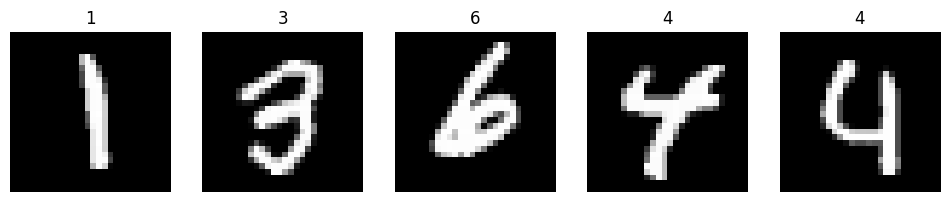

Batch shape: torch.Size([128, 784])
Single image shape: torch.Size([784])


In [3]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    img = images[i].view(28, 28)  
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'{labels[i]}')
    axes[i].axis('off')
plt.show()

print(f"Batch shape: {images.shape}")
print(f"Single image shape: {images[0].shape}")

## 1. Modelling

Sampling new data points from $p_{\text{data}}$ is impossible, so we aim to make an appoximator parameterized with $p_\phi$.$\\$
A Standard VAE models this through encoders and decoders as below.
$$\text{Data point }x\in\mathbb R^D,\quad\text{Latent vector } z\in\mathbb R^d\quad(D>>d)$$
$$x\sim p_{\text{data}},\quad z\sim q_\theta(z|x),\quad x'\sim p_\phi(x|z)\\$$
At inference, a latent vector $z$ is sampled from a prior distribution $p_{\text{prior}}:=\mathcal N(0,\mathbf I)$ and a data point is sampled from $p_\phi(x|z)$.

Now, if we are to train this architecture to approximate $p_{\text{data}}$ as we first intended, a KL Divergence would be a common choice.
$$\mathcal D_{\text{KL}}(p_{\text{data}}|p_\phi)=\mathbb E_{x\sim p_{\text{data}}}[\log{p_{\text{data}}(x)} - \log{p_{\phi}(x)}]$$
Here we can observe that the computation of $p_\phi(x)$ is inevitable. But, such term is intractable, due to the integral form through the latent space.
$$p_\phi(x)=\int p(x|z)p_{\text{prior}}(z)dz$$
To tackle such problem, the VAE architecture leverages the encoding layer.

By Baye's rule, the posterior distribution is given as below.
$$p_\phi(z|x)=\frac{p_\phi(x|z)p_{\text{prior}}(z)}{p_\phi(x)}=\frac{p_\phi(x|z)p_{\text{prior}}(z)}{\int p(x|z)p_{\text{prior}}(z)dz}$$
This term is stil also intractable, due to the marginal likelihood $p_\phi(x)$. However, we can approximate the encoder to the posterior distribution as below.
$$q_\theta(z|x)\approx p_\phi(z|x)$$

Now with the posterior approximator, we can introduce a lower bound error term for the intractable MLE.
$$\log{p_\phi(x)}\geq\mathcal L_{\text{ELBO}}(\theta,\phi;x)$$
$$\mathcal L_{\text{ELBO}}(\theta,\phi;x)=\mathbb E_{z\sim q_\theta(z|x)}[\log{p_\phi(x|z)}]-\mathcal D_{\text{KL}}(q_\theta(z|x)|p_{\text{prior}}(z))$$
The inequality can be easily proven.
$$\mathcal L_{\text{ELBO}}=\mathbb E_{z\sim q_\theta{z|x}}\log[\frac{p_\phi(x|z)p_{\text{prior}}(z)}{q_\theta(z|x)}]=\int q_\theta(z|x) \log\frac{p_\phi(x|z)p_{\text{prior}}(z)}{q_\theta(z|x)}dz\leq\log\int q_\theta(z|x) \frac{p_\phi(x|z)p_{\text{prior}}(z)}{q_\theta(z|x)}dz=\log p_\phi(x)$$

In practice, such loss would be calculated as a reconstruction loss term from data set $\mathcal X$ and a latent regularization term.

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

A Standard implementation of VAEs are the Gaussian VAEs to ensure pdf conditions (normalization & non-negativity).
$$q_\theta(z|x):=\mathcal N(z;\mu_\theta(x),\text{diag}(\sigma^2_\theta(x))),\quad\text{where }\mu_\theta:\mathbb R^D\to\mathbb R^d,\space\sigma_\theta:\mathbb R^D\to\mathbb R^d_+$$
$$p_\phi(x|z):=\mathcal N(x;\mu_\phi(z),\sigma^2\mathbf I),\quad\text{where }\mu_\phi:\mathbb R^d\to\mathbb R^D,\space\sigma\in\mathbb R_+$$

In [6]:
class Gaussian_VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20, decoder_var=1.0):
        super().__init__()
        self.decoder_var = decoder_var
        
        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, input_dim)
    
    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar) # logvar -> std
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        h = F.relu(self.fc2(z))
        x_mu = self.fc_out(h)
        return x_mu
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z) # During Training, we use the mean for reconstruction
        return x_recon, mu, logvar

In [7]:
class prior_distribution:
    @staticmethod
    def log_prob(z):
        # Standard normal prior
        return -0.5 * torch.sum(z**2 + torch.log(2 * torch.pi * torch.ones_like(z)), dim=1)

With this architecture, the ELBO loss function is given as below
$$\mathcal L_{\text{ELBO}}(\theta,\phi;x)=\mathbb E_{z\sim q_\theta(z|x)}[\log{p_\phi(x|z)}]-\mathcal D_{\text{KL}}(q_\theta(z|x)|p_{\text{prior}}(z))$$
$$\mathbb E_{z\sim q_\theta(z|x)}[\log{p_\phi(x|z)}]=\mathbb E_{z\sim q_\theta(z|x)}[\log{\mathcal N(x;\mu_\phi(z),\sigma^2\mathbf I)}]=-\frac{1}{2\sigma^2}\mathbb E_{z\sim q_\theta(z|x)}||x-\mu_\phi(z)||^2+C$$
$$\mathcal D_{\text{KL}}(q_\theta(z|x)|p_{\text{prior}}(z))=\mathbb E_{z\sim q_\theta(z|x)}[\log{q_\theta(z|x)}-\log{p_{\text{prior}}(z)}] = \mathbb E_{z\sim q_\theta(z|x)}\left[-\frac{1}{2}||z-\mu_\theta(x)||^2_{\text{diag}(\sigma_\theta^{-2}(x))} + \frac{1}{2}||z||^2 + C\right]$$
Therefore the final loss function is given as
$$\mathcal L_{\text{ELBO}}(\theta,\phi;x):=\mathbb E_{z\sim q_\theta(z|x)}\left[-\frac{1}{2\sigma^2}||x-\mu_\phi(z)||^2+\frac{1}{2}||z-\mu_\theta(x)||^2_{\text{diag}(\sigma_\theta^{-2}(x))} - \frac{1}{2}||z||^2\right]$$
In practice, the ELBO loss is summed through a given dataset $\mathcal X=\{x_i|i\in \mathbb Z_N \}$.

In [8]:
class ELBO_Loss:
    @staticmethod
    def compute(x, x_recon, mu, logvar, decoder_var):
        # Reconstruction Loss
        recon_loss = -0.5 * torch.sum((x - x_recon)**2) / decoder_var
        
        # KL Divergence
        kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        
        # ELBO
        elbo = recon_loss - kl_div
        return -elbo  # We minimize negative ELBO

## 2. Train

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [11]:
model = Gaussian_VAE(input_dim=784, hidden_dim=400, latent_dim=20, decoder_var=1.0).to(device)
prior = prior_distribution()
criterion = ELBO_Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [15]:
train_epoch = 100
for epoch in range(train_epoch):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = model(data)
        loss = criterion.compute(data, x_recon, mu, logvar, model.decoder_var)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    avg_loss = train_loss / len(train_loader.dataset)

    test_loss = 0
    model.eval()
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            x_recon, mu, logvar = model(data)
            loss = criterion.compute(data, x_recon, mu, logvar, model.decoder_var)
            test_loss += loss.item()
    avg_test_loss = test_loss / len(test_loader.dataset)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Average Loss: {avg_loss:.4f}, Test Loss: {avg_test_loss:.4f}')

Epoch 10, Average Loss: 18.9838
Epoch 20, Average Loss: 18.9544
Epoch 30, Average Loss: 18.9444
Epoch 40, Average Loss: 18.9452
Epoch 50, Average Loss: 18.9022
Epoch 60, Average Loss: 18.9094
Epoch 70, Average Loss: 18.9069
Epoch 80, Average Loss: 18.8877
Epoch 90, Average Loss: 18.8830
Epoch 100, Average Loss: 18.8794


## 3. Inference

A trained VAEs have 2 main KPIs for inference.
1. Sample generation from $p_{\text{prior}}$ with the learned decoder $p_\phi(x|z)$
2. Reconstruction task for test samples

5 Samples generated from prior distribution:


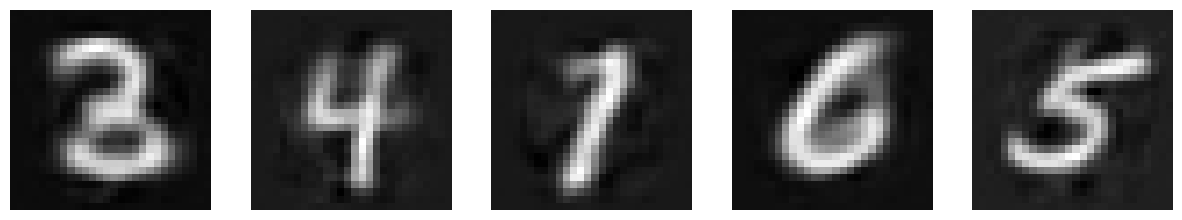

In [17]:
n=5
print(f"{n} Samples generated from prior distribution:")

samples = []
model.eval()
with torch.no_grad():
    z = torch.randn(n, 20).to(device)
    sample = model.decode(z)
    samples.append(sample.cpu().view(-1, 28, 28))

fig, axes = plt.subplots(1, n, figsize=(15, 3))
for i in range(n):
    axes[i].imshow(samples[0][i], cmap='gray')
    axes[i].axis('off')
plt.show()

5 Reconstructions from test set:


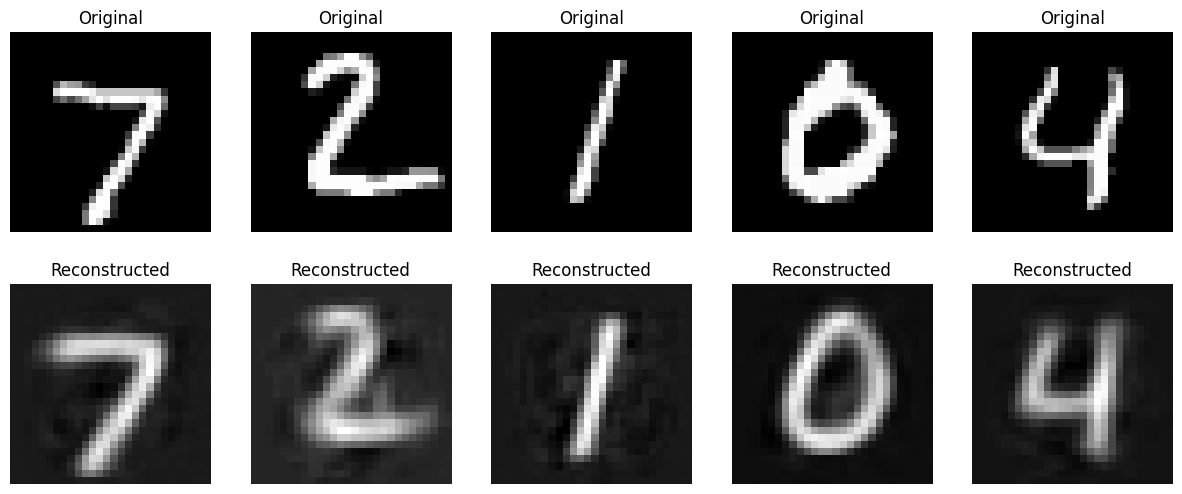

In [22]:
n=5
print(f"{n} Reconstructions from test set:")

samples = []
model.eval()
with torch.no_grad():
    data, _ = next(iter(test_loader))
    data = data.to(device)[:n]
    x_recon, _, _ = model(data)
    samples.append((data.cpu().view(-1, 28, 28), x_recon.cpu().view(-1, 28, 28)))

fig, axes = plt.subplots(2, n, figsize=(15, 6))
for i in range(n):
    axes[0, i].imshow(samples[0][0][i], cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(samples[0][1][i], cmap='gray')
    axes[1, i].set_title('Reconstructed')
    axes[1, i].axis('off')
plt.show()

## 4. Heirarchical VAEs

To model Complex data distributions, a Heirarchical VAE is often used. This architecture uses multiple layers of latent vectors.
$$p_\phi(x|z_{1:L})=p_\phi(x|z_1)\Pi_{i=2}^Lp_\phi(z_{i-1}|z_i)p(z_L)$$
$$q_\theta(z_{1:L}|x)=q_\theta(z_1|x)\Pi_{i=2}^Lq_\theta(z_{i}|z_{i-1})$$
Every Other implementations remain unchanged.

However, such architecture does not resolve the problem of multi-peak families or ignore *z* solutions etc.
Instead, the HVAE lets the model learn and orthogonalize different signals to different layers, boosting the downstream task performance.